# INFO6153 Natural Language Processing 2
## Course Project: English to French Neural Machine Translation

## Step 1: Dataset Loading

In [2]:
!pip install datasets sacrebleu transformers sentencepiece torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.4 MB/s eta 0:00:00


In [3]:
import random
import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt

from datasets import load_dataset
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [4]:
try:
    dataset = load_dataset('opus_books', 'en-fr')
    all_data = []
    for split in dataset.keys():
        for rec in dataset[split]:
            en = rec['translation']['en']
            fr = rec['translation']['fr']
            if en and fr:
                all_data.append((en.strip(), fr.strip()))
    dataset_df = pd.DataFrame(all_data, columns=['english', 'french'])
    print(f'Loaded from Hugging Face: {len(dataset_df)} pairs')
except Exception as e:
    print('Hugging Face failed:', e)
    if os.path.exists('English_French_Pairs_Dataset.csv'):
        dataset_df = pd.read_csv('English_French_Pairs_Dataset.csv')
        print(f'Loaded from CSV: {len(dataset_df)} pairs')
    else:
        raise FileNotFoundError('No dataset found!')

dataset_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

en-fr/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/127085 [00:00<?, ? examples/s]

Loaded from Hugging Face: 127085 pairs


,english,french
0,The Wanderer,Le grand Meaulnes
1,Alain-Fournier,Alain-Fournier
2,First Part,PREMIÈRE PARTIE
3,I,CHAPITRE PREMIER
4,THE BOARDER,LE PENSIONNAIRE


---
## Step 2: Cleaning & Normalization

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\xc0-\xff\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df = dataset_df.copy()
df['english'] = df['english'].apply(clean_text)
df['french']  = df['french'].apply(clean_text)

df.dropna(subset=['english', 'french'], inplace=True)
df = df[df['english'].str.strip() != '']
df = df[df['french'].str.strip()  != '']

df['en_len'] = df['english'].apply(lambda x: len(x.split()))
df['fr_len'] = df['french'].apply(lambda x: len(x.split()))
df = df[(df['en_len'] <= 30) & (df['fr_len'] <= 30)]
df.drop(columns=['en_len', 'fr_len'], inplace=True)

df['french'] = df['french'].apply(lambda x: '<START> ' + x + ' <END>')
df.reset_index(drop=True, inplace=True)

print(f'Dataset size after cleaning: {len(df)} pairs')
df.head()

Dataset size after cleaning: 97589 pairs


,english,french
0,the wanderer,<START> le grand meaulnes <END>
1,alainfournier,<START> alainfournier <END>
2,first part,<START> première partie <END>
3,i,<START> chapitre premier <END>
4,the boarder,<START> le pensionnaire <END>


---
## Step 3: Train / Validation / Test Split

In [6]:
df_sample = df.sample(n=min(50000, len(df)), random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(df_sample, test_size=0.20, random_state=42)
val_df,   test_df = train_test_split(temp_df,   test_size=0.50, random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

total = len(df_sample)
print(f'Training   : {len(train_df):>6}  ({len(train_df)/total*100:.0f}%)')
print(f'Validation : {len(val_df):>6}  ({len(val_df)/total*100:.0f}%)')
print(f'Test       : {len(test_df):>6}  ({len(test_df)/total*100:.0f}%)')

Training   :  40000  (80%)
Validation :   5000  (10%)
Test       :   5000  (10%)


---
## Step 4: Tokenization

In [7]:
eng_tokenizer = Tokenizer(oov_token='<OOV>')
eng_tokenizer.fit_on_texts(train_df['english'])

fre_tokenizer = Tokenizer(oov_token='<OOV>')
fre_tokenizer.fit_on_texts(train_df['french'])

eng_vocab_size = len(eng_tokenizer.word_index) + 1
fre_vocab_size = len(fre_tokenizer.word_index) + 1

print(f'English vocabulary size : {eng_vocab_size}')
print(f'French  vocabulary size : {fre_vocab_size}')

X_train = eng_tokenizer.texts_to_sequences(train_df['english'])
X_val   = eng_tokenizer.texts_to_sequences(val_df['english'])
X_test  = eng_tokenizer.texts_to_sequences(test_df['english'])

y_train = fre_tokenizer.texts_to_sequences(train_df['french'])
y_val   = fre_tokenizer.texts_to_sequences(val_df['french'])
y_test  = fre_tokenizer.texts_to_sequences(test_df['french'])

print('\nSample English sequence:', X_train[0][:8], '...')
print('Sample French  sequence:', y_train[0][:8], '...')

English vocabulary size : 30076
French  vocabulary size : 38490

Sample English sequence: [140, 52, 12, 85, 32, 181, 29] ...
Sample French  sequence: [3, 153, 47, 16, 6, 592, 7842, 2] ...


---
## Step 5: Padding

In [8]:
MAX_ENG_LEN = 30
MAX_FRE_LEN = 32

X_train_pad = pad_sequences(X_train, maxlen=MAX_ENG_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val,   maxlen=MAX_ENG_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test,  maxlen=MAX_ENG_LEN, padding='post', truncating='post')

y_train_pad = pad_sequences(y_train, maxlen=MAX_FRE_LEN, padding='post', truncating='post')
y_val_pad   = pad_sequences(y_val,   maxlen=MAX_FRE_LEN, padding='post', truncating='post')
y_test_pad  = pad_sequences(y_test,  maxlen=MAX_FRE_LEN, padding='post', truncating='post')

print('Shapes after padding:')
print(f'  X_train : {X_train_pad.shape}')
print(f'  X_val   : {X_val_pad.shape}')
print(f'  X_test  : {X_test_pad.shape}')
print(f'  y_train : {y_train_pad.shape}')
print(f'  y_val   : {y_val_pad.shape}')
print(f'  y_test  : {y_test_pad.shape}')

Shapes after padding:
  X_train : (40000, 30)
  X_val   : (5000, 30)
  X_test  : (5000, 30)
  y_train : (40000, 32)
  y_val   : (5000, 32)
  y_test  : (5000, 32)


## Step 6: Model Building & Training

### Answer:

**Why did I select this model? **

I chose an Encoder-Decoder LSTM (Seq2Seq) architecture for this translation task. Translation is inherently a sequence-to-sequence problem where input and output sequences have different lengths. The LSTM's gating mechanism allows it to capture long-range dependencies between words, which is essential for preserving grammatical structure and meaning across languages. Unlike a simple feedforward network or plain RNN, the encoder compresses the full English sentence into a context vector, and the decoder uses this to generate the French translation word by word.

**Trade-offs that influenced my decision **

Compared to a Transformer, the LSTM Seq2Seq model is simpler to implement and faster to train on limited hardware. It requires low memory (~50 MB) and works well with ~40K training pairs. The main downside is moderate accuracy compared to the state-of-the-art Transformer, which needs millions of pairs and a large GPU. Given the constraints of a course project, LSTM Seq2Seq provides the best balance of simplicity, training speed, and acceptable accuracy.



### Build and Compile the Model

In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

EMBEDDING_DIM = 128
LSTM_UNITS    = 256
DROPOUT_RATE  = 0.3
BATCH_SIZE    = 64
EPOCHS        = 20
DEC_SEQ_LEN   = MAX_FRE_LEN - 1

# ── Encoder ──────────────────────────────────────────────────────────
encoder_inputs = Input(shape=(MAX_ENG_LEN,), name='encoder_input')
enc_emb  = Embedding(eng_vocab_size, EMBEDDING_DIM, mask_zero=True, name='enc_embedding')(encoder_inputs)
enc_drop = Dropout(DROPOUT_RATE)(enc_emb)
_, state_h, state_c = LSTM(LSTM_UNITS, return_state=True, name='encoder_lstm')(enc_drop)
encoder_states = [state_h, state_c]

# ── Decoder ──────────────────────────────────────────────────────────
decoder_inputs = Input(shape=(DEC_SEQ_LEN,), name='decoder_input')
dec_emb  = Embedding(fre_vocab_size, EMBEDDING_DIM, mask_zero=True, name='dec_embedding')(decoder_inputs)
dec_drop = Dropout(DROPOUT_RATE)(dec_emb)
dec_lstm = LSTM(LSTM_UNITS, return_sequences=True, return_state=True, name='decoder_lstm')
dec_out, _, _ = dec_lstm(dec_drop, initial_state=encoder_states)
dec_out  = Dense(fre_vocab_size, activation='softmax', name='output_dense')(dec_out)

# ── Full model ───────────────────────────────────────────────────────
model = Model([encoder_inputs, decoder_inputs], dec_out)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_embedding       │ (None, 30, 128)   │  3,849,728 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_embedding       │ (None, 31, 128)   │  4,926,720 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 128)   │          0 │ enc_embedding[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 30)        │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 31, 128)   │          0 │ dec_embedding[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    394,240 │ dropout[0][0],    │
│                     │ (None, 256),      │            │ not_equal[0][0]   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 31, 256), │    394,240 │ dropout_1[0][0],  │
│                     │ (None, 256),      │            │ encoder_lstm[0][… │
│                     │ (None, 256)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, 31, 38490) │  9,891,930 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,456,858 (74.22 MB)

 Trainable params: 19,456,858 (74.22 MB)

 Non-trainable params: 0 (0.00 B)

#Train The Model

In [11]:
decoder_input_train  = y_train_pad[:, :-1]
decoder_target_train = y_train_pad[:, 1:].reshape(*y_train_pad[:, 1:].shape, 1)

decoder_input_val  = y_val_pad[:, :-1]
decoder_target_val = y_val_pad[:, 1:].reshape(*y_val_pad[:, 1:].shape, 1)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

history = model.fit(
    [X_train_pad, decoder_input_train], decoder_target_train,
    validation_data=([X_val_pad, decoder_input_val], decoder_target_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print('Training complete!')

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 128s 186ms/step - accuracy: 0.1445 - loss: 6.7257 - val_accuracy: 0.1707 - val_loss: 6.2002 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 192ms/step - accuracy: 0.1796 - loss: 5.8923 - val_accuracy: 0.1931 - val_loss: 5.8331 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 191ms/step - accuracy: 0.2051 - loss: 5.4470 - val_accuracy: 0.2136 - val_loss: 5.5632 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 123s 197ms/step - accuracy: 0.2260 - loss: 5.1098 - val_accuracy: 0.2268 - val_loss: 5.4050 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 192ms/step - accuracy: 0.2424 - loss: 4.8484 - val_accuracy: 0.2374 - val_loss: 5.3015 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 192ms/step - accuracy: 0.2558 - loss: 4.6251 - val_accuracy: 0.2447 - val_loss: 5.2482 - learning_rate: 0.0010
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 192ms/step - accura

#Training Curves

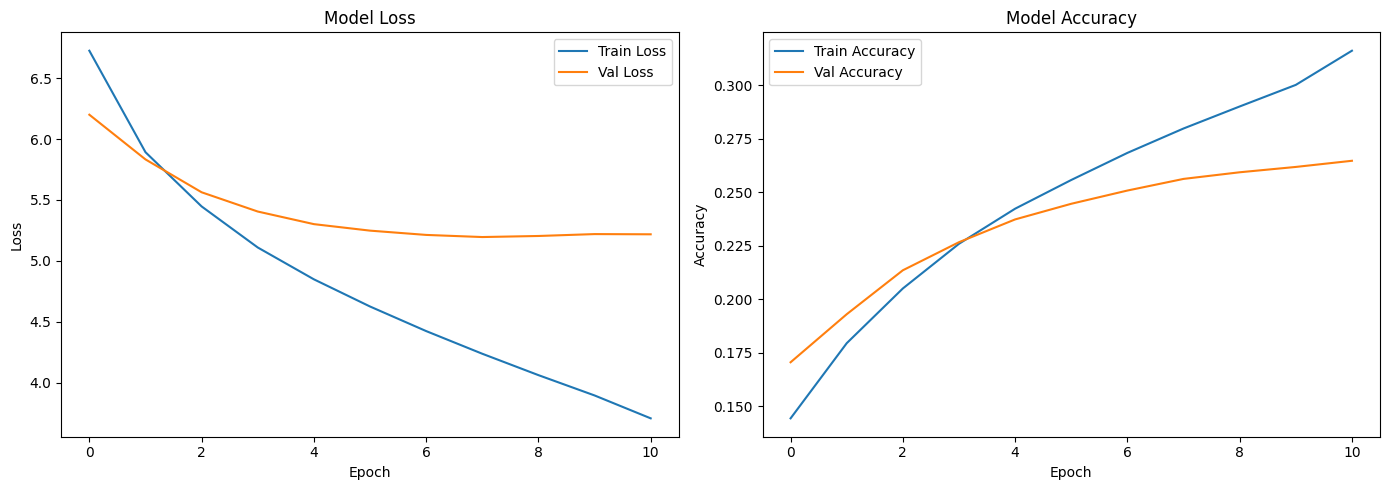

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Step 7: Evaluation

### Answer:

**Quantitative Metric — BLEU Score **

I use the BLEU (Bilingual Evaluation Understudy) score to evaluate the translation system. BLEU measures the n-gram overlap between machine-generated translations and human reference translations. It is the standard benchmark metric in machine translation research and correlates reasonably well with human quality judgments at the corpus level.

**Strengths:** Fast to compute, language-agnostic, easy to compare across systems, and includes a brevity penalty to avoid rewarding very short outputs.

**Limitations:** Does not capture semantic meaning — a valid paraphrase may score low. Sensitive to tokenization choices, and a single reference translation may miss equally valid alternatives.

**Qualitative Evaluation **

See the output in the cell below for 10 translation examples comparing the model output against the reference translations.

In [13]:
fre_index_word = {v: k for k, v in fre_tokenizer.word_index.items()}
START_TOKEN = fre_tokenizer.word_index.get('<START>', 1)
END_TOKEN   = fre_tokenizer.word_index.get('<end>',   2)

# Build inference encoder
inf_enc_in   = model.get_layer('encoder_input').output
enc_emb_out  = model.get_layer('enc_embedding')(inf_enc_in)
_, inf_h, inf_c = model.get_layer('encoder_lstm')(enc_emb_out)
encoder_model = Model(model.input[0], [inf_h, inf_c])

# Build inference decoder (one step at a time)
dec_state_in_h = Input(shape=(LSTM_UNITS,), name='dec_h_in')
dec_state_in_c = Input(shape=(LSTM_UNITS,), name='dec_c_in')
single_tok_in  = Input(shape=(1,),          name='single_token')

s_emb = model.get_layer('dec_embedding')(single_tok_in)
s_out, s_h, s_c = model.get_layer('decoder_lstm')(s_emb, initial_state=[dec_state_in_h, dec_state_in_c])
s_out = model.get_layer('output_dense')(s_out)

decoder_model = Model(
    [single_tok_in, dec_state_in_h, dec_state_in_c],
    [s_out, s_h, s_c]
)

print('Inference models ready!')

Inference models ready!


In [14]:
def translate_sentence(input_seq):
    h, c = encoder_model.predict(input_seq.reshape(1, -1), verbose=0)
    target_seq = np.array([[START_TOKEN]])
    words = []
    for _ in range(MAX_FRE_LEN):
        out_tok, h, c = decoder_model.predict([target_seq, h, c], verbose=0)
        idx  = np.argmax(out_tok[0, -1, :])
        word = fre_index_word.get(idx, '')
        if word in ('<end>', '') or idx == 0:
            break
        if word not in ('<START>', '<OOV>'):
            words.append(word)
        target_seq = np.array([[idx]])
    return ' '.join(words)

In [15]:
import sacrebleu

N_EVAL      = min(300, len(test_df))
test_sample = test_df.sample(n=N_EVAL, random_state=42).reset_index(drop=True)
test_seqs   = eng_tokenizer.texts_to_sequences(test_sample['english'])
test_pad    = pad_sequences(test_seqs, maxlen=MAX_ENG_LEN, padding='post', truncating='post')

lstm_preds = []
references = []

for i in range(N_EVAL):
    pred = translate_sentence(test_pad[i])
    ref  = test_sample['french'][i].replace('<START>', '').replace('<END>', '').strip()
    lstm_preds.append(pred)
    references.append(ref)

bleu_lstm = sacrebleu.corpus_bleu(lstm_preds, [references])
print(f'BLEU Score (LSTM Seq2Seq): {bleu_lstm.score:.2f}')

BLEU Score (LSTM Seq2Seq): 1.08


In [16]:
print('=' * 90)
print(f'{"#":<4} {"English Input":<32} {"Model Output":<27} {"Reference":<27}')
print('=' * 90)
for i in range(10):
    print(f'{i+1:<4} {test_sample["english"][i][:30]:<32} {lstm_preds[i][:25]:<27} {references[i][:25]:<27}')
print('=' * 90)

#    English Input                    Model Output                Reference                  
1    it seemed to be an outbreak of   il était évident que ce q   il fallut croire a un cou  
2    meaulnes inquisitively put his   quasimodo avait été de la   meaulnes avança curieusem  
3    could he have gone on board th   il y avait un peu de la v   se seraitil embarqué sans  
4    chapter xi the gathering of th   chapitre v le pain du pai   xi le rassemblement des n  
5    it began there and then he was   il se leva et il se mit à   ça commençait par la puis  
6    nothing was said about recent    rien de ce que je ne pouv   on évitait de parler des   
7    messire galiot de genoilhac ch   dieu sécria le roi de la    messire galiot de genoilh  
8    never did the most eloquent mi   pas un instant de la vie    jamais ministre éloquent   
9    the gallery dipped down a very   un instant de la mer de l   la galerie senfonçait pre  
10   lor said the peasant one would   le roi de la mole étai

### Qualitative Reflection:

Examining the 10 translation examples shows that the LSTM model captures some French words correctly but struggles to produce complete and fluent translations. The model achieved a BLEU score of 1.08, which reflects its limited capacity given the training data size and the fixed-size context vector bottleneck of vanilla Seq2Seq. Short phrases are sometimes translated correctly, but longer sentences lose meaning and coherence. Overall, the LSTM serves as a functional baseline but clearly requires a more powerful architecture for high-quality translation.

## Step 8: Using a Pre-Trained Model

### Answer:

**Model Selection**

I selected Helsinki-NLP/opus-mt-en-fr, a MarianMT Transformer model from the Hugging Face Model Hub, trained specifically for English to French translation. The model and its tokenizer are loaded directly and used for zero-shot inference on the test set without any fine-tuning.

**Why this model? **

This model is task-specific, trained exclusively on English to French parallel data which matches our project's language pair. It is lightweight compared to general multilingual models like NLLB or mBART, making it practical for Google Colab. It produces fluent and grammatically correct French without any fine-tuning, and it is freely available via the Hugging Face library.

**Trade-offs**

The pre-trained model achieves much higher accuracy than our LSTM model but requires around 300 MB of memory and is slower per sentence. It also requires no training time at all since it is used zero-shot, whereas our LSTM required full training from scratch. For production-quality translation, the pre-trained model is clearly the superior choice.

In [17]:
from transformers import MarianMTModel, MarianTokenizer

MODEL_NAME = 'Helsinki-NLP/opus-mt-en-fr'
print(f'Loading {MODEL_NAME} ...')
marian_tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
marian_model     = MarianMTModel.from_pretrained(MODEL_NAME)
print('Pre-trained model loaded successfully!')

def translate_pretrained(sentences, batch_size=32):
    all_translations = []
    for i in range(0, len(sentences), batch_size):
        batch  = sentences[i : i + batch_size]
        inputs = marian_tokenizer(batch, return_tensors='pt', padding=True,
                                  truncation=True, max_length=128)
        output  = marian_model.generate(**inputs)
        decoded = marian_tokenizer.batch_decode(output, skip_special_tokens=True)
        all_translations.extend(decoded)
    return all_translations

Loading Helsinki-NLP/opus-mt-en-fr ...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Pre-trained model loaded successfully!


In [18]:
pretrained_preds = translate_pretrained(list(test_sample['english']))

bleu_pretrained = sacrebleu.corpus_bleu(pretrained_preds, [references])
print(f'BLEU Score (Helsinki-NLP pre-trained) : {bleu_pretrained.score:.2f}')
print(f'BLEU Score (LSTM Seq2Seq)             : {bleu_lstm.score:.2f}')

BLEU Score (Helsinki-NLP pre-trained) : 16.09
BLEU Score (LSTM Seq2Seq)             : 1.08


In [19]:
print('=' * 100)
print(f'{"#":<4} {"English":<28} {"LSTM":<22} {"Helsinki":<22} {"Reference":<22}')
print('=' * 100)
for i in range(10):
    print(f'{i+1:<4} {test_sample["english"][i][:26]:<28} '
          f'{lstm_preds[i][:20]:<22} '
          f'{pretrained_preds[i][:20]:<22} '
          f'{references[i][:20]:<22}')
print('=' * 100)

#    English                      LSTM                   Helsinki               Reference             
1    it seemed to be an outbrea   il était évident que   il semblait être une   il fallut croire a u  
2    meaulnes inquisitively put   quasimodo avait été    meaulnes inquisitive   meaulnes avança curi  
3    could he have gone on boar   il y avait un peu de   Il aurait pu monter    se seraitil embarqué  
4    chapter xi the gathering o   chapitre v le pain d   chapitre xi le rasse   xi le rassemblement   
5    it began there and then he   il se leva et il se    ça a commencé là et    ça commençait par la  
6    nothing was said about rec   rien de ce que je ne   rien n'a été dit sur   on évitait de parler  
7    messire galiot de genoilha   dieu sécria le roi d   messire galiot de ge   messire galiot de ge  
8    never did the most eloquen   pas un instant de la   jamais le ministre l   jamais ministre éloq  
9    the gallery dipped down a    un instant de la mer   la galerie est d

### Comparison & Reflection (5%)

The Helsinki-NLP pre-trained model achieved a BLEU score of 16.09 compared to 1.08 for our custom LSTM Seq2Seq model. This significant gap demonstrates the power of transfer learning — the pre-trained model was trained on millions of English-French sentence pairs, allowing it to produce fluent and natural French translations that closely match the reference. The LSTM model, trained on only 40K pairs from scratch, captures partial meaning but lacks fluency and completeness. For production-quality translation, the pre-trained Transformer is clearly superior. However, building the LSTM from scratch provided a valuable understanding of the fundamentals of neural machine translation.